<a href="https://colab.research.google.com/github/Leoncio-Sanchez/-modelo-de-precisi-n/blob/main/ecommerce%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.cluster import KMeans

In [30]:
data = pd.read_csv('ecommerce_data_2.csv')
data

,fecha_venta,cliente_id,marca,producto,precio_unitario,descuento_porcentaje,precio_final_unidad,cantidad,tipo_pago,ingreso_total
0,01-01-22,1946,Adidas,Abrigo,153.04,19.87,122.63,1,Efectivo,122.63
1,01-01-22,629,Levis,Zapatilla,122.69,5.86,115.50,1,Tarjeta,115.50
2,01-01-22,1595,Platanitos,Camiseta,59.90,14.59,51.16,1,Tarjeta,51.16
3,01-01-22,696,Zara,Pantalón,54.25,4.12,52.02,4,Tarjeta,208.08
4,01-01-22,2866,Mango,Accesorio,22.99,14.70,19.61,2,Tarjeta,39.21
...,...,...,...,...,...,...,...,...,...,...
9995,12-31-24,2938,Platanitos,Accesorio,17.20,6.48,16.08,1,Efectivo,16.08
9996,12-31-24,876,Nike,Abrigo,158.34,10.94,141.01,1,Tarjeta,141.01
9997,12-31-24,1597,Platanitos,Abrigo,213.11,8.11,195.82,1,Tarjeta,195.82
9998,12-31-24,1433,Adidas,Accesorio,12.29,5.89,11.57,2,Tarjeta,23.13


In [31]:
nueva_data = data.drop(columns=['fecha_venta', 'cliente_id', 'marca', 'producto', 'tipo_pago'], axis=1)

In [32]:
nueva_data.to_csv('archivo_modificado.csv', index=False)

In [33]:
data = pd.read_csv('archivo_modificado.csv')
data

,precio_unitario,descuento_porcentaje,precio_final_unidad,cantidad,ingreso_total
0,153.04,19.87,122.63,1,122.63
1,122.69,5.86,115.50,1,115.50
2,59.90,14.59,51.16,1,51.16
3,54.25,4.12,52.02,4,208.08
4,22.99,14.70,19.61,2,39.21
...,...,...,...,...,...
9995,17.20,6.48,16.08,1,16.08
9996,158.34,10.94,141.01,1,141.01
9997,213.11,8.11,195.82,1,195.82
9998,12.29,5.89,11.57,2,23.13


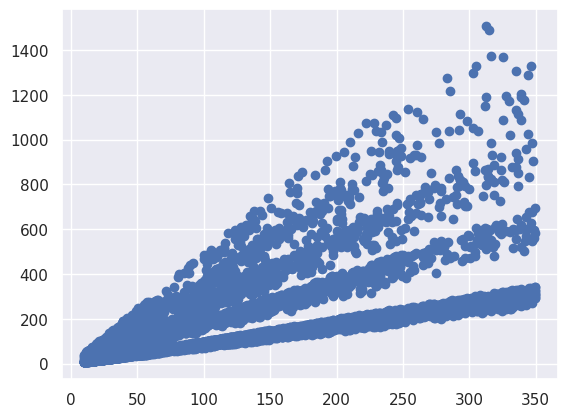

In [39]:
plt.scatter(data['precio_unitario'], data['ingreso_total'])
plt.show()

In [54]:
x = data[['precio_unitario', 'ingreso_total']]
x


,precio_unitario,ingreso_total
0,153.04,122.63
1,122.69,115.50
2,59.90,51.16
3,54.25,208.08
4,22.99,39.21
...,...,...
9995,17.20,16.08
9996,158.34,141.01
9997,213.11,195.82
9998,12.29,23.13


In [55]:
kmeans = KMeans(n_clusters = 3)
kmeans.fit(x)
identified_clusters = kmeans.fit_predict(x)
identified_clusters


array([0, 0, 0, ..., 1, 0, 2], dtype=int32)

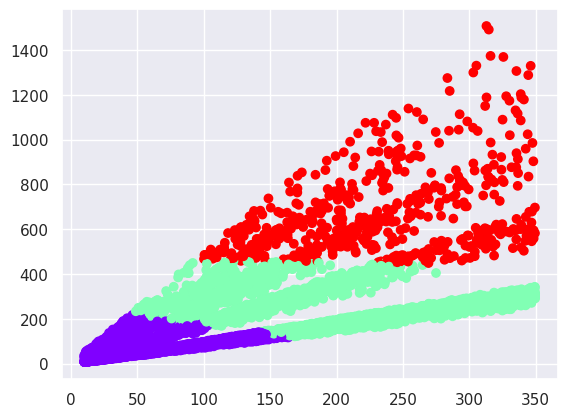

In [56]:
data_con_cluster = data.copy()
data_con_cluster['clusters'] = identified_clusters # agrgando la columna clusters
plt.scatter(data_con_cluster['precio_unitario'], data_con_cluster['ingreso_total'], c=data_con_cluster['clusters'], cmap='rainbow')
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


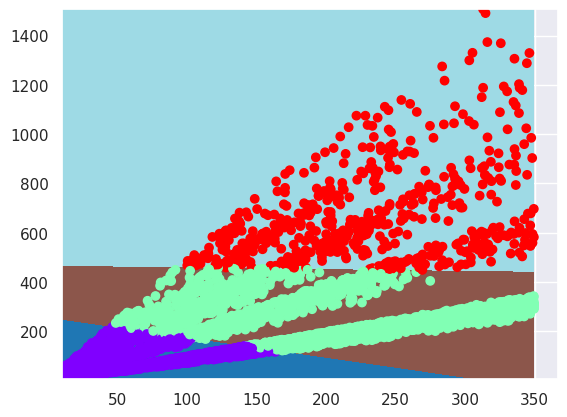

In [57]:
#  definicion de regiones

h = 0.1
x_min , x_max = min(data['precio_unitario']), max(data['precio_unitario'])
y_min , y_max = min(data['ingreso_total']),  max(data['ingreso_total'])

xx , yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h)) # para crear las regiones
stack1 = np.dstack((xx.flatten(), yy.flatten()))[0,:,:]
y_pred = kmeans.predict(stack1)
vb = y_pred.reshape(np.shape(xx))
plt.pcolormesh(xx, yy, vb, cmap='tab20')
plt.scatter(data_con_cluster['precio_unitario'], data['ingreso_total'], c=data_con_cluster['clusters'], cmap='rainbow')
plt.show()


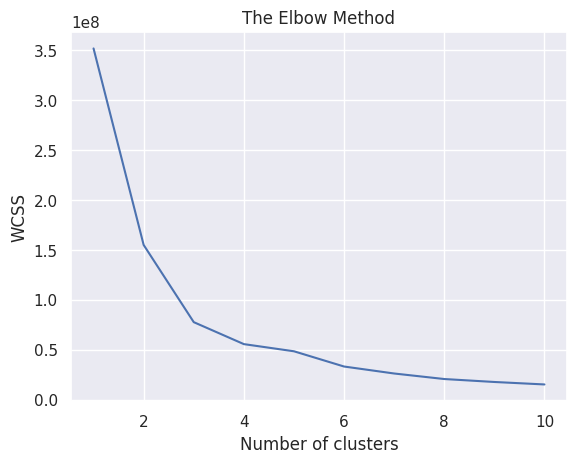

In [58]:
#determinando  el número de cluster (metodo wcss y  elbow )

wcss = []
for i in range(1, 11):
    kmeans = KMeans(i)
    kmeans.fit(x)
    wcss_iter = kmeans.inertia_
    wcss.append(wcss_iter)

number_clusters = range(1, 11)
plt.plot(number_clusters, wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()



In [59]:
#ordenando  con  4  grupos

kmeans = KMeans(n_clusters = 2)
kmeans.fit(x)
identified_clusters = kmeans.fit_predict(x)
identified_clusters

array([0, 0, 0, ..., 0, 0, 1], dtype=int32)

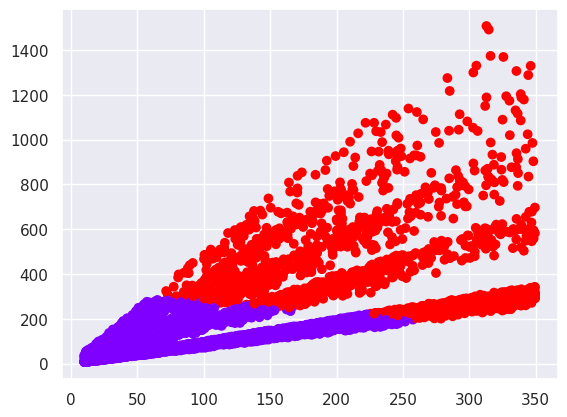

In [61]:
data_con_cluster = data.copy()
data_con_cluster['clusters'] = identified_clusters # agrgando la columna clusters
plt.scatter(data_con_cluster['precio_unitario'], data_con_cluster['ingreso_total'], c=data_con_cluster['clusters'], cmap='rainbow')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


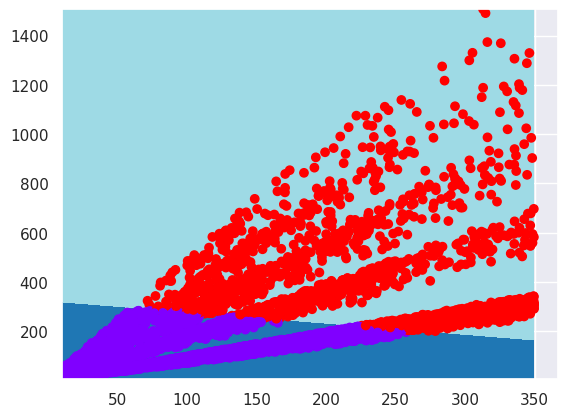

In [62]:
#  definicion de regiones

h = 0.1
x_min , x_max = min(data['precio_unitario']), max(data['precio_unitario'])
y_min , y_max = min(data['ingreso_total']),  max(data['ingreso_total'])

xx , yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h)) # para crear las regiones
stack1 = np.dstack((xx.flatten(), yy.flatten()))[0,:,:]
y_pred = kmeans.predict(stack1)
vb = y_pred.reshape(np.shape(xx))
plt.pcolormesh(xx, yy, vb, cmap='tab20')
plt.scatter(data_con_cluster['precio_unitario'], data['ingreso_total'], c=data_con_cluster['clusters'], cmap='rainbow')
plt.show()
